# Convolutional Neural Network II: Classification d'objets Recyclables ou Non

In [173]:
import os


In [174]:
data_dir = "datasets/WASTE"


In [175]:
train_dir = os.path.join(data_dir, "TRAIN")
test_dir = os.path.join(data_dir, "TEST")


In [176]:
os.listdir(train_dir)


['O', 'R']

In [177]:
train_r_dir = os.path.join(train_dir, "R")
train_o_dir = os.path.join(train_dir, "O")


In [178]:
len(os.listdir(train_r_dir)), len(os.listdir(train_o_dir))


(9999, 12565)

In [179]:
from tabulate import tabulate
import os

train_r_count = len(os.listdir(train_r_dir))
train_o_count = len(os.listdir(train_o_dir))
test_r_count = len(os.listdir(os.path.join(test_dir, "R")))
test_o_count = len(os.listdir(os.path.join(test_dir, "O")))

total_r = train_r_count + test_r_count
total_o = train_o_count + test_o_count
total_train = train_r_count + train_o_count
total_test = test_r_count + test_o_count
grand_total = total_train + total_test


data = [
    ["Recyclable (R)", train_r_count, test_r_count, total_r],
    ["Organic (O)", train_o_count, test_o_count, total_o],
    ["Cumulative", total_train, total_test, grand_total]
]

headers = ["Category", "Train", "Test", "Cumulative"]

print(tabulate(data, headers=headers, tablefmt="grid"))


+----------------+---------+--------+--------------+
| Category       |   Train |   Test |   Cumulative |
+================+=========+========+==============+
| Recyclable (R) |    9999 |   1112 |        11111 |
+----------------+---------+--------+--------------+
| Organic (O)    |   12565 |   1401 |        13966 |
+----------------+---------+--------+--------------+
| Cumulative     |   22564 |   2513 |        25077 |
+----------------+---------+--------+--------------+


In [180]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


In [181]:
r_index = 568
o_index = 1596

recyclable_imgs = [os.path.join(train_r_dir, filename) for filename in os.listdir(train_r_dir)]
organic_imgs = [os.path.join(train_o_dir, filename) for filename in os.listdir(train_o_dir)]

img_r = mpimg.imread(recyclable_imgs[r_index])
img_o = mpimg.imread(organic_imgs[o_index])


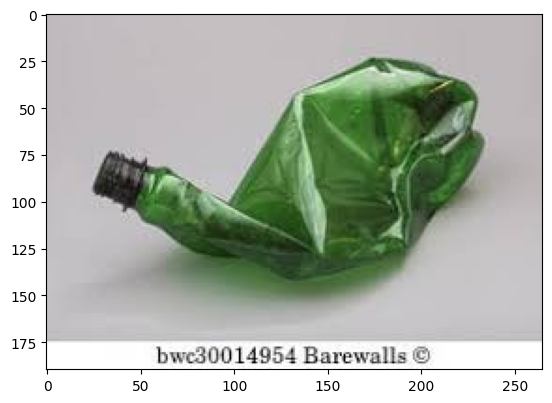

In [182]:
plt.imshow(img_r)


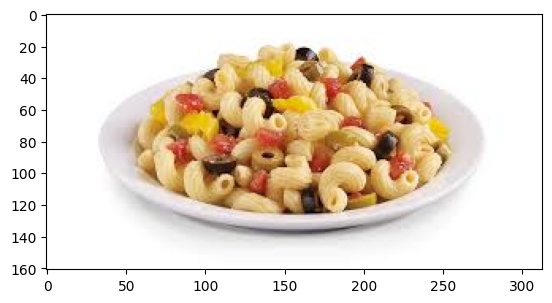

In [183]:
plt.imshow(img_o)


In [184]:
# training_labels.shape # Inconnu ! → Solution = ImageDataGenerator


## ImageDataGenerator

In [185]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [186]:
train_data_generator = ImageDataGenerator(rescale=1/255.0)
test_data_generator = ImageDataGenerator(rescale=1/255.0)


In [187]:
train_generator = train_data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_data_generator.flow_from_directory(
    directory = test_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"
)


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [188]:
batch_images, batch_labels = next(iter(train_generator))


In [189]:
batch_images.shape


(32, 224, 224, 3)

In [190]:
batch_labels.shape, batch_labels


((32,),
 array([0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1.,
        1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0.],
       dtype=float32))

In [191]:
train_generator.class_indices


{'O': 0, 'R': 1}

In [192]:
labels = list(train_generator.class_indices.keys())
labels


['O', 'R']

Image # 30 - Label: O


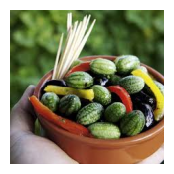

In [193]:
import tensorflow as tf
import matplotlib.pyplot as plt

index = 30

print(f"Image # {index} - Label:", labels[int(batch_labels[index])])

# Create a figure and axes with a size that makes the image appear around 112x112
# The exact figsize might need some trial and error depending on your display
plt.figure(figsize=(2, 2)) # Adjust figsize as needed to get the desired visual size

# Display the original size image from the batch
img_to_display = batch_images[index]
plt.imshow(img_to_display)

# Turn off the axis
plt.axis('off')

plt.show()


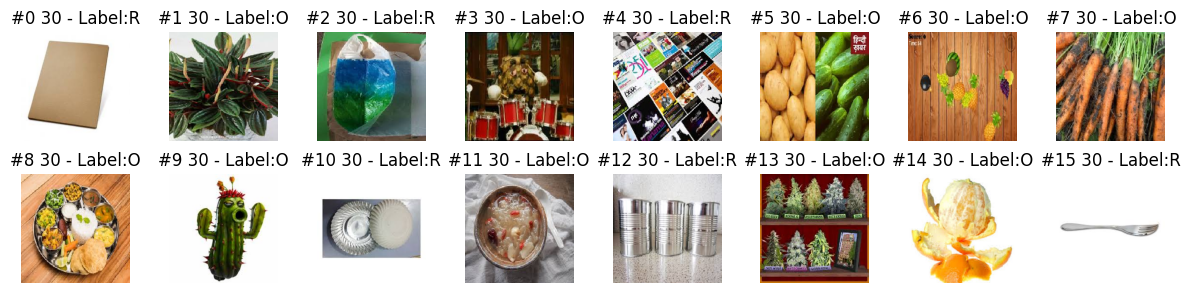

In [194]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt

nb_imgs = 16 # Max 32 car batch en contient que 32
random_indices = random.sample(range(0, batch_images.shape[0]), nb_imgs) # Get 10 random indices from the batch (content 32)

# Determine the number of rows and columns for the subplots
n_images = len(random_indices)
n_cols = 8 # You can adjust the number of columns as needed
n_rows = (n_images + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5)) # Adjust figure size for smaller visual display

for i, img_index in enumerate(random_indices):
  plt.subplot(n_rows, n_cols, i + 1)
  plt.imshow(batch_images[img_index]) # Display the original size image from the batch

  plt.title(labels[int(batch_labels[img_index])])
  plt.title(f"#{i} {index} - Label:"+labels[int(batch_labels[img_index])])
  plt.axis('off')

# Adjust subplot spacing
plt.tight_layout()
plt.subplots_adjust(wspace=.1, hspace=.3) # Adjust wspace (width space) and hspace (height space) as needed


plt.show()


## Modeling

In [195]:
import tensorflow as tf


In [196]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])


In [197]:
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 110, 110, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,385 (9.92 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [198]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)


In [199]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [200]:
def chrono():
    import time

    def decorator(func):
        def wrapper(*args, **kwargs):
            start_time = time.time()
            result = func(*args, **kwargs)
            end_time = time.time()
            duration = end_time - start_time
            minutes = int(duration // 60)
            seconds = duration % 60
            print(f"Execution time of {func.__name__}: {minutes:02d}:{seconds:06.3f}")
            return result

        return wrapper

    return decorator


In [201]:
# @chrono()
# h = model.fit(train_generator, epochs=1,
#              validation_data=test_generator,
#              callbacks = [model_ckp, stop])


In [202]:
pip install pydot


Note: you may need to restart the kernel to use updated packages.


In [203]:
@chrono()
def train_model(model, train_generator, test_generator, epochs=99):
  history = model.fit(
    train_generator, 
    epochs=epochs,
    validation_data=test_generator,
    callbacks=[model_ckp, stop]
  )
  return history

# Capture the history 
h = train_model(model, train_generator, test_generator)


Epoch 1/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.7417 - loss: 0.6912

706/706 ━━━━━━━━━━━━━━━━━━━━ 603s 853ms/step - accuracy: 0.7878 - loss: 0.5013 - val_accuracy: 0.8675 - val_loss: 0.3516
Epoch 2/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.8303 - loss: 0.3968

706/706 ━━━━━━━━━━━━━━━━━━━━ 581s 823ms/step - accuracy: 0.8369 - loss: 0.3862 - val_accuracy: 0.8814 - val_loss: 0.3101
Epoch 3/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 566s 801ms/step - accuracy: 0.8587 - loss: 0.3443 - val_accuracy: 0.8762 - val_loss: 0.3479
Epoch 4/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8646 - loss: 0.3247

706/706 ━━━━━━━━━━━━━━━━━━━━ 566s 802ms/step - accuracy: 0.8691 - loss: 0.3231 - val_accuracy: 0.8818 - val_loss: 0.3358
Epoch 5/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 569s 805ms/step - accuracy: 0.8804 - loss: 0.2971 - val_accuracy: 0.8488 - val_loss: 0.3513
Epoch 6/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.8948 - loss: 0.2656

706/706 ━━━━━━━━━━━━━━━━━━━━ 569s 806ms/step - accuracy: 0.8942 - loss: 0.2698 - val_accuracy: 0.8926 - val_loss: 0.3033
Epoch 7/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 777ms/step - accuracy: 0.9059 - loss: 0.2418

706/706 ━━━━━━━━━━━━━━━━━━━━ 566s 802ms/step - accuracy: 0.9057 - loss: 0.2435 - val_accuracy: 0.9021 - val_loss: 0.3114
Epoch 8/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 604s 855ms/step - accuracy: 0.9203 - loss: 0.2142 - val_accuracy: 0.8914 - val_loss: 0.3352
Epoch 9/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 765s 1s/step - accuracy: 0.9340 - loss: 0.1781 - val_accuracy: 0.8619 - val_loss: 0.4961
Epoch 10/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 653s 924ms/step - accuracy: 0.9463 - loss: 0.1445 - val_accuracy: 0.8806 - val_loss: 0.5586
Epoch 11/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 689s 977ms/step - accuracy: 0.9581 - loss: 0.1172 - val_accuracy: 0.8882 - val_loss: 0.6145
Epoch 12/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - accuracy: 0.9668 - loss: 0.0964 - val_accuracy: 0.8790 - val_loss: 0.5176
Epoch 13/99
706/706 ━━━━━━━━━━━━━━━━━━━━ 886s 1s/step - accuracy: 0.9735 - loss: 0.0865 - val_accuracy: 0.8846 - val_loss: 0.5919
Epoch 14/99
691/706 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9804 - loss: 0.0646

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
OSError: [Errno 22] Invalid argument: 'datasets/WASTE\\TRAIN\\O\\O_6803.jpg'
Traceback (most recent call last):

  File "c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)

  File "c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 264, in _finite_generator
   

In [ ]:
# pip install pydot
tf.keras.utils.plot_model(model)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):

  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label='accuracy', c='r')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve")
  plt.legend()
  plt.grid()
  plt.show()

def plot_accuracy_curve(history):

  plt.plot(list(range(len(history['accuracy']))), history['accuracy'], label = "accuracy")
  plt.plot(list(range(len(history['val_accuracy']))), history['val_accuracy'], label="val_accuracy")
  plt.xlabel('Epochs')
  plt.ylabel("accuracy")
  plt.title("Accuracy Curve")
  plt.legend(loc='upper left')
  plt.grid()
  plt.show()


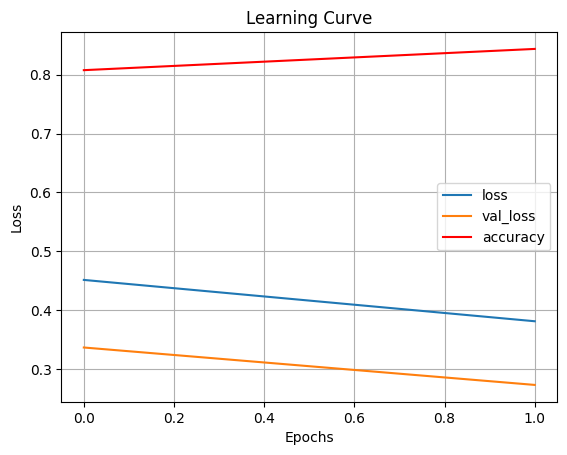

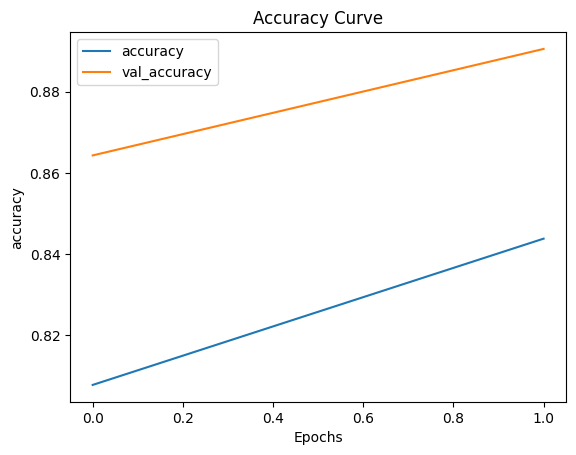

The best validation accuracy achieved was: 0.8906 at epoch 2


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(h.history)
best_val_accuracy = max(h.history["val_accuracy"])
print(f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}")


In [ ]:
# Nombre d'itérations = Nombres de train / nombre batch_size=32 (Du ImageDataGenerator)
22564/32


705.125

In [ ]:
# model_save = tf.keras.models.load_model('best_model.h5')
# model_save.evaluate(train_generator, test_generator)


## Data Augmentation

In [ ]:
# avant augmentation
train_data_generator = ImageDataGenerator(rescale=1/255.0)
test_data_generator = ImageDataGenerator(rescale=1/255.0)


# après augmentation
train_data_generator = ImageDataGenerator(rescale=1/255.0,
                                          rotation_range=40,
                                          width_shift_range=0.2,
                                          height_shift_range=0.2,
                                          shear_range=0.2,
                                          zoom_range=0.2,
                                          horizontal_flip=True,
                                          fill_mode="nearest")
test_data_generator = ImageDataGenerator(rescale=1/255.0)


In [ ]:
train_generator = train_data_generator.flow_from_directory(
    directory = train_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"

)


test_generator = test_data_generator.flow_from_directory(
    directory = test_dir,
    target_size = (224, 224),
    batch_size=32,
    class_mode="binary"

)


Found 22564 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [ ]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
])


In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
# h = model.fit(train_generator, epochs=50,
#              validation_data=test_generator,
#              callbacks = [model_ckp, stop])
h = train_model(model, train_generator, test_generator)


Epoch 1/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7528 - loss: 0.5473

c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


706/706 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - accuracy: 0.7900 - loss: 0.4760 - val_accuracy: 0.8532 - val_loss: 0.3686
Epoch 2/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8135 - loss: 0.4244

706/706 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - accuracy: 0.8200 - loss: 0.4157 - val_accuracy: 0.8766 - val_loss: 0.3349
Execution time of train_model: 28:30.080


In [ ]:
# loss: 0.2942 - accuracy: 0.8854 - val_loss: 0.2266 - val_accuracy: 0.9180
# loss: 0.3518 - accuracy: 0.8522 - val_loss: 0.2764 - val_accuracy: 0.8957


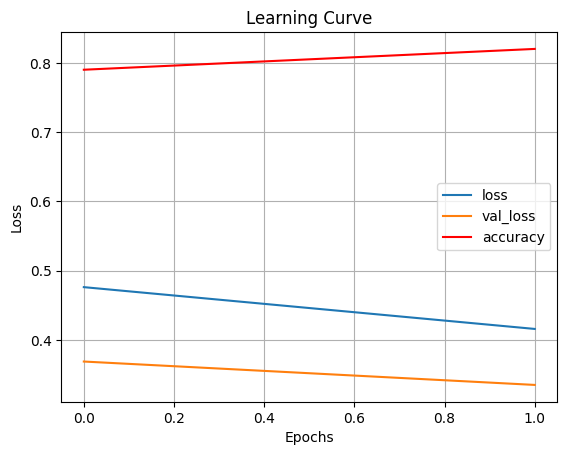

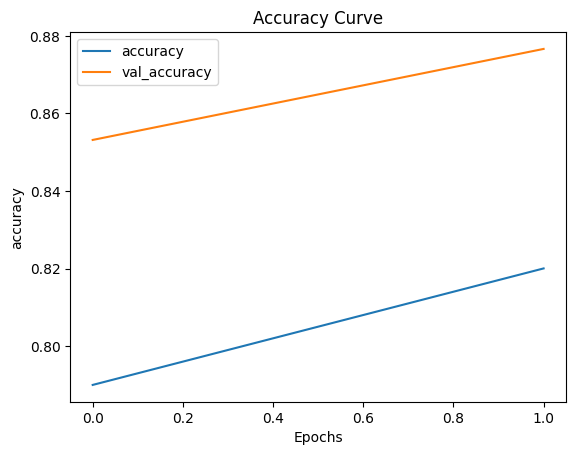

The best validation accuracy achieved was: 0.8766 at epoch 2


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(h.history)
best_val_accuracy = max(h.history["val_accuracy"])
print(
    f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}"
)


## Transfert Learning


In [ ]:
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 110, 110, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 53, 53, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,200,772 (19.84 MB)

 Trainable params: 2,600,385 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,600,387 (9.92 MB)

## Extraction de caractéristiques

In [ ]:
from tensorflow.keras.applications import vgg16


In [ ]:
pretrained_model = vgg16.VGG16(include_top=True, weights='imagenet', input_shape=(224, 224, 3))


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 106s 0us/step


In [ ]:
pretrained_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pretrained_model = vgg16.VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
pretrained_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# (32, 224, 224, 3) ==> (32, 7, 7, 512)


### API Sequential

In [ ]:
model = tf.keras.models.Sequential([

    #Extraction de caractéristiques
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),

    # applatir
    tf.keras.layers.Flatten(),

    # Dense
    tf.keras.layers.Dense(units=128, activation="relu"),
    tf.keras.layers.Dense(units=1, activation="sigmoid"),
                ])


c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model = tf.keras.models.Sequential()


In [ ]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu', input_shape=(224, 224,3)))


In [ ]:
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(tf.keras.layers.MaxPooling2D(2,2))


In [ ]:
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

### Api functional

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x =  tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3))(inputs)
x = tf.keras.layers.MaxPooling2D(2,2)(x)
outputs = tf.keras.layers.Flatten()(x)


In [ ]:
model = tf.keras.Model(inputs, outputs)


### Utilisation des filtres de VGG 16

In [ ]:
pretrained_model.trainable = False


In [ ]:
flatten_layer = tf.keras.layers.Flatten()


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = pretrained_model(inputs, training=False)
x = flatten_layer(x) # 7*7*512
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)


model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
# h = model.fit(train_generator, epochs=50,
#              validation_data=test_generator,
#              callbacks = [model_ckp, stop])
h = train_model(model, train_generator, test_generator)


Epoch 1/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7781 - loss: 0.9230

706/706 ━━━━━━━━━━━━━━━━━━━━ 2604s 4s/step - accuracy: 0.8235 - loss: 0.5364 - val_accuracy: 0.8595 - val_loss: 0.3753
Epoch 2/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8778 - loss: 0.3078

706/706 ━━━━━━━━━━━━━━━━━━━━ 1835s 3s/step - accuracy: 0.8795 - loss: 0.3003 - val_accuracy: 0.8711 - val_loss: 0.3357
Execution time of train_model: 74:01.439


In [ ]:
# loss: 0.2942 - accuracy: 0.8854 - val_loss: 0.2266 - val_accuracy: 0.9180
# loss: 0.3518 - accuracy: 0.8522 - val_loss: 0.2764 - val_accuracy: 0.8957
# loss: 0.2165 - accuracy: 0.9160 - val_loss: 0.3172 - val_accuracy: 0.8926


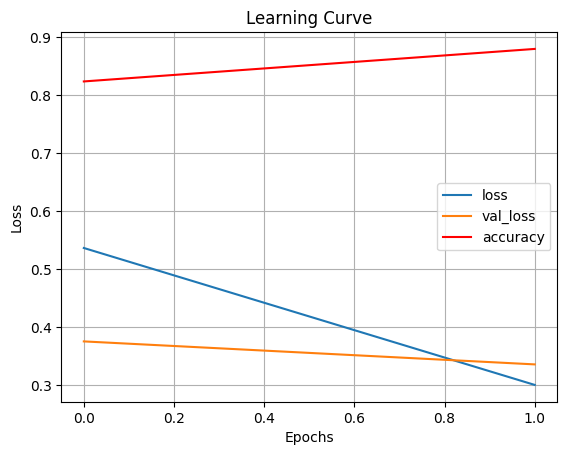

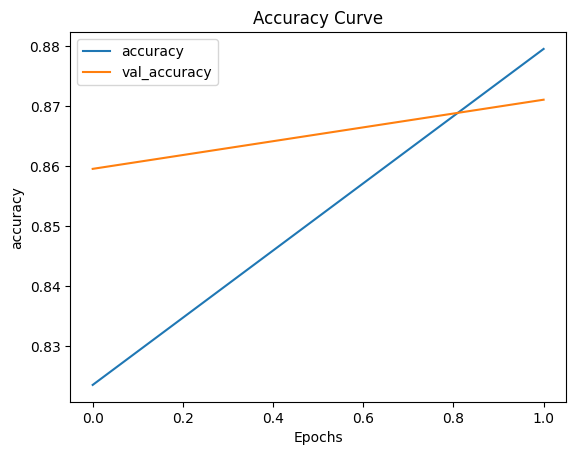

The best validation accuracy achieved was: 0.8711 at epoch 2


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(h.history)
best_val_accuracy = max(h.history["val_accuracy"])
print(
    f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}"
)


## Fine Tuning

In [ ]:
pretrained_model.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
pretrained_model.layers


[<InputLayer name=input_layer_6, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>,
 <Conv2D name=block5_conv1, built=True>,
 <Conv2D name=block5_conv2, built=True>,
 <Conv2D name=block5_conv3, built=True>,
 <MaxPooling2D name=block5_pool, built=True>]

In [ ]:
pretrained_model.trainable=True


In [ ]:
pretrained_model.layers[:-4]


[<InputLayer name=input_layer_6, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <MaxPooling2D name=block1_pool, built=True>,
 <Conv2D name=block2_conv1, built=True>,
 <Conv2D name=block2_conv2, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <Conv2D name=block3_conv1, built=True>,
 <Conv2D name=block3_conv2, built=True>,
 <Conv2D name=block3_conv3, built=True>,
 <MaxPooling2D name=block3_pool, built=True>,
 <Conv2D name=block4_conv1, built=True>,
 <Conv2D name=block4_conv2, built=True>,
 <Conv2D name=block4_conv3, built=True>,
 <MaxPooling2D name=block4_pool, built=True>]

In [ ]:
for layer in pretrained_model.layers[:-4]:
  layer.trainable = False


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = pretrained_model(inputs, training=False)
x = flatten_layer(x) # 7*7*512
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)


model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 10,290,945 (39.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="aug_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=['accuracy'])


In [ ]:
# h = model.fit(train_generator, epochs=50,
#              validation_data=test_generator,
#              callbacks = [model_ckp, stop])
h = train_model(model, train_generator, test_generator)


Epoch 1/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5529 - loss: 2.8331

706/706 ━━━━━━━━━━━━━━━━━━━━ 2126s 3s/step - accuracy: 0.5560 - loss: 1.0371 - val_accuracy: 0.5575 - val_loss: 0.6866
Epoch 2/2
706/706 ━━━━━━━━━━━━━━━━━━━━ 2125s 3s/step - accuracy: 0.5569 - loss: 0.6868 - val_accuracy: 0.5575 - val_loss: 0.6865
Execution time of train_model: 70:51.000


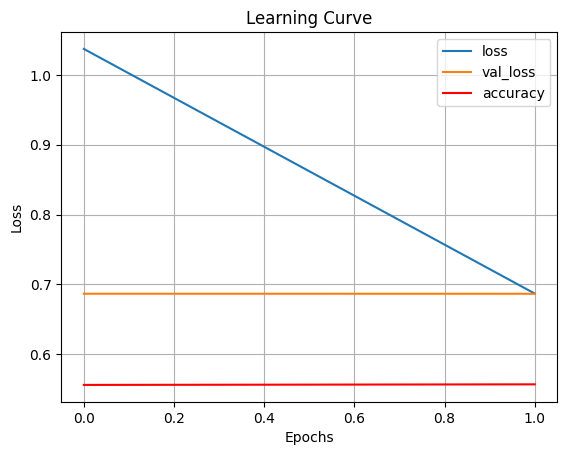

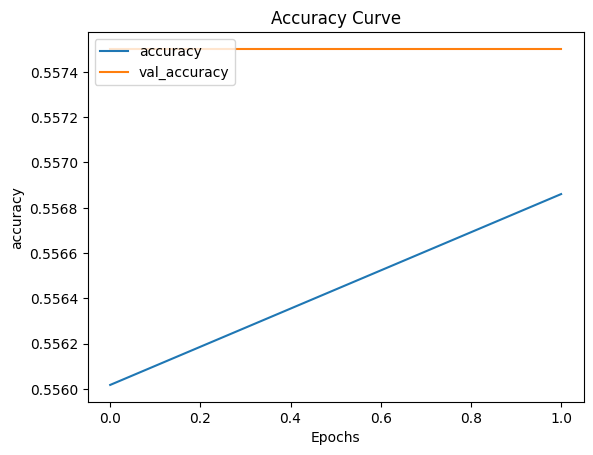

The best validation accuracy achieved was: 0.5575 at epoch 1


In [ ]:
plot_learning_curve(h.history)
plot_accuracy_curve(h.history)
best_val_accuracy = max(h.history["val_accuracy"])
print(
    f"The best validation accuracy achieved was: {max(h.history['val_accuracy']):.4f} at epoch {h.history['val_accuracy'].index(best_val_accuracy) + 1}"
)
